# 100 - Voronoi 分割アプローチ: Firestore 向けベクトル検索

## 目的

Firestore では全件走査が発生するため、**Voronoi 分割**（ボロノイ分割）でデータを事前にクラスタリングし、
`WHERE pivot_id IN [...]` の完全一致条件で候補を ~1000 件に絞り込んだ上で kNN を行う。

### 2つのパターンを比較
- **パターン A**: コサイン類似度空間で直接 Voronoi 分割（512-D ArcFace embedding）
- **パターン B**: ITQ-LSH 128bit 経由で Voronoi 分割（Hamming 空間）

### 評価指標
- **BF-Recall@K**: Brute-force Top-K との一致率
- **Cluster Recall@K**: 同一人物（同一クラスタ）の発見率
- **候補数**: pivot_id フィルタ後の実際の候補数（Firestore 読み取り数に直結）

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
from collections import Counter
from sklearn.cluster import KMeans, MiniBatchKMeans

from image_vector_poc.search.lsh.itq import ITQLSH

DB_PATH = Path("../data/images.duckdb")
MODEL_DIR = Path("../data/itq_models")

conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

# 全顔埋め込みとメタデータを取得
rows = conn.execute("""
    SELECT f.face_id, f.embedding, f.cluster_id
    FROM face_detections f
    WHERE f.model_name = 'insightface/buffalo_l'
    ORDER BY f.face_id
""").fetchall()

face_ids = [r[0] for r in rows]
embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
cluster_ids = [r[2] for r in rows]
fid_to_idx = {fid: i for i, fid in enumerate(face_ids)}

print(f"Total faces: {len(face_ids)}")
print(f"Embedding shape: {embeddings.shape}")

# L2正規化（コサイン類似度 = 内積にするため）
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings_normed = embeddings / norms
print(f"Norm range after normalization: [{np.linalg.norm(embeddings_normed, axis=1).min():.4f}, {np.linalg.norm(embeddings_normed, axis=1).max():.4f}]")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total faces: 75162
Embedding shape: (75162, 512)


Norm range after normalization: [1.0000, 1.0000]


## 1. クエリ構築と Brute-force Ground Truth

NB99 と同じ手法: cluster_id が 3人以上のクラスタから、各メンバーをクエリとし、同一クラスタの他メンバーを正解とする。

In [2]:
# クラスタ別の顔インデックスを収集
cluster_members = {}
for i, cid in enumerate(cluster_ids):
    if cid is not None:
        cluster_members.setdefault(cid, []).append(i)

# 3メンバー以上のクラスタを対象
MIN_CLUSTER_SIZE = 3
valid_clusters = {cid: members for cid, members in cluster_members.items() if len(members) >= MIN_CLUSTER_SIZE}

print(f"全クラスタ数: {len(cluster_members)}")
print(f"3人以上のクラスタ数: {len(valid_clusters)}")

size_dist = Counter(len(m) for m in valid_clusters.values())
for size in sorted(size_dist.keys()):
    print(f"  {size}人: {size_dist[size]} クラスタ")

# 各クラスタからクエリを構築
queries = []
for cid in sorted(valid_clusters.keys()):
    members = valid_clusters[cid]
    for q_idx in members:
        gt_indices = [m for m in members if m != q_idx]
        queries.append({
            "query_idx": q_idx,
            "cluster_id": cid,
            "gt_indices": gt_indices,
        })

print(f"\n総クエリ数: {len(queries)}")

# Brute-force Ground Truth
TOP_K_VALUES = [1, 5, 10, 20, 30, 50]
MAX_K = max(TOP_K_VALUES)

ground_truth = {}
for qi, q in enumerate(queries):
    q_emb = embeddings_normed[q["query_idx"]]
    sims = embeddings_normed @ q_emb
    sims[q["query_idx"]] = -1  # 自分自身を除外
    top_indices = np.argsort(-sims)[:MAX_K]
    top_scores = sims[top_indices]
    ground_truth[qi] = {
        "indices": top_indices,
        "scores": top_scores,
    }

print(f"Ground truth computed: {len(ground_truth)} queries, top-{MAX_K}")

# BF Cluster Recall
for k in [5, 10, 20, 30]:
    recalls = []
    for qi, q in enumerate(queries):
        gt_set = set(ground_truth[qi]["indices"][:k])
        cluster_gt = set(q["gt_indices"])
        found = len(gt_set & cluster_gt)
        recalls.append(found / len(cluster_gt) if cluster_gt else 0.0)
    print(f"BF Cluster Recall@{k}: {np.mean(recalls):.4f}")

全クラスタ数: 60
3人以上のクラスタ数: 23
  3人: 7 クラスタ
  4人: 5 クラスタ
  5人: 1 クラスタ
  6人: 4 クラスタ
  7人: 2 クラスタ
  8人: 2 クラスタ
  20人: 1 クラスタ
  42人: 1 クラスタ

総クエリ数: 162


Ground truth computed: 162 queries, top-50
BF Cluster Recall@5: 0.3693
BF Cluster Recall@10: 0.4472
BF Cluster Recall@20: 0.5317
BF Cluster Recall@30: 0.5740


## 2. パターン A: コサイン空間での Voronoi 分割（直接 512-D）

512次元の正規化ベクトル空間で k-means クラスタリングを行い、ピボット（セントロイド）を生成する。
各顔は最も近いピボットの ID を持つ。検索時はクエリと全ピボットのコサイン類似度を計算し、上位ピボットの候補を取得。

### パラメータスイープ
- ピボット数: 64, 128, 256, 512
- 検索時の上位ピボット数: 1, 2, 3, 4, 5, 8

In [3]:
N_PIVOTS_LIST = [64, 128, 256, 512]
TOP_PIVOTS_LIST = [1, 2, 3, 4, 5, 8]
N_DATA = len(embeddings_normed)

# --- パターン A: コサイン空間 k-means ---
cosine_voronoi_results = {}

for n_pivots in N_PIVOTS_LIST:
    print(f"\n{'='*60}")
    print(f"k-means with {n_pivots} pivots (cosine space)")
    print(f"{'='*60}")
    
    # k-means（正規化ベクトルなので spherical k-means に近い）
    t0 = time.perf_counter()
    kmeans = MiniBatchKMeans(n_clusters=n_pivots, random_state=42, batch_size=2048, n_init=3)
    pivot_labels = kmeans.fit_predict(embeddings_normed)
    centroids = kmeans.cluster_centers_
    # セントロイドも正規化
    centroids_normed = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
    t_fit = time.perf_counter() - t0
    
    # ピボットごとのデータ数
    pivot_sizes = np.bincount(pivot_labels, minlength=n_pivots)
    print(f"  Fit time: {t_fit:.2f}s")
    print(f"  Pivot sizes: min={pivot_sizes.min()}, max={pivot_sizes.max()}, "
          f"mean={pivot_sizes.mean():.1f}, median={np.median(pivot_sizes):.0f}")
    
    # 各ピボットに属するインデックスを事前計算
    pivot_to_indices = {}
    for i, pid in enumerate(pivot_labels):
        pivot_to_indices.setdefault(pid, []).append(i)
    
    # 検索シミュレーション
    for n_top in TOP_PIVOTS_LIST:
        if n_top > n_pivots:
            continue
        
        bf_recalls = {k: [] for k in TOP_K_VALUES}
        cluster_recalls = {k: [] for k in TOP_K_VALUES}
        candidate_counts = []
        
        for qi, q in enumerate(queries):
            q_emb = embeddings_normed[q["query_idx"]]
            
            # クエリと全ピボットのコサイン類似度
            pivot_sims = centroids_normed @ q_emb
            top_pivot_ids = np.argsort(-pivot_sims)[:n_top]
            
            # 候補インデックスを収集
            candidates = []
            for pid in top_pivot_ids:
                candidates.extend(pivot_to_indices[pid])
            candidate_counts.append(len(candidates))
            
            # 候補内でコサイン類似度 rerank
            cand_indices = np.array(candidates)
            cand_sims = embeddings_normed[cand_indices] @ q_emb
            # 自分自身を除外
            self_mask = cand_indices != q["query_idx"]
            cand_indices = cand_indices[self_mask]
            cand_sims = cand_sims[self_mask]
            
            sorted_order = np.argsort(-cand_sims)
            result_indices = cand_indices[sorted_order]
            
            for k in TOP_K_VALUES:
                result_set = set(result_indices[:k])
                # BF-Recall
                bf_set = set(ground_truth[qi]["indices"][:k])
                bf_recalls[k].append(len(result_set & bf_set) / k if k > 0 else 0.0)
                # Cluster Recall
                cluster_gt = set(q["gt_indices"])
                found = len(result_set & cluster_gt)
                cluster_recalls[k].append(found / len(cluster_gt) if cluster_gt else 0.0)
        
        mean_cands = np.mean(candidate_counts)
        key = (n_pivots, n_top)
        cosine_voronoi_results[key] = {
            "mean_candidates": mean_cands,
            "bf_recall": {k: np.mean(v) for k, v in bf_recalls.items()},
            "cluster_recall": {k: np.mean(v) for k, v in cluster_recalls.items()},
        }
        
        print(f"  top_pivots={n_top}: candidates={mean_cands:.0f} "
              f"BF-R@10={np.mean(bf_recalls[10]):.4f} "
              f"BF-R@30={np.mean(bf_recalls[30]):.4f} "
              f"CR@30={np.mean(cluster_recalls[30]):.4f}")


k-means with 64 pivots (cosine space)


  Fit time: 1.12s
  Pivot sizes: min=67, max=3844, mean=1174.4, median=1219


  top_pivots=1: candidates=1208 BF-R@10=0.6062 BF-R@30=0.5800 CR@30=0.2758


  top_pivots=2: candidates=2461 BF-R@10=0.6969 BF-R@30=0.6755 CR@30=0.3120


  top_pivots=3: candidates=3743 BF-R@10=0.7599 BF-R@30=0.7444 CR@30=0.3550


...

  Fit time: 7.69s
  Pivot sizes: min=1, max=2455, mean=146.8, median=61
  top_pivots=1: candidates=267 BF-R@10=0.6142 BF-R@30=0.5994 CR@30=0.3197
  top_pivots=2: candidates=469 BF-R@10=0.6969 BF-R@30=0.6947 CR@30=0.3585


  top_pivots=3: candidates=699 BF-R@10=0.7272 BF-R@30=0.7348 CR@30=0.3582


  top_pivots=4: candidates=906 BF-R@10=0.7537 BF-R@30=0.7626 CR@30=0.3594


  top_pivots=5: candidates=1138 BF-R@10=0.7772 BF-R@30=0.7887 CR@30=0.3655


  top_pivots=8: candidates=1826 BF-R@10=0.8056 BF-R@30=0.8208 CR@30=0.3758


In [4]:
# パターン A 結果テーブル
rows_a = []
for (n_pivots, n_top), res in sorted(cosine_voronoi_results.items()):
    rows_a.append({
        "pivots": n_pivots,
        "top_k_pivots": n_top,
        "mean_candidates": res["mean_candidates"],
        "cand_ratio": res["mean_candidates"] / N_DATA,
        "BF-R@1": res["bf_recall"][1],
        "BF-R@5": res["bf_recall"][5],
        "BF-R@10": res["bf_recall"][10],
        "BF-R@30": res["bf_recall"][30],
        "CR@10": res["cluster_recall"][10],
        "CR@30": res["cluster_recall"][30],
    })

df_a = pd.DataFrame(rows_a)
print("パターン A: コサイン空間 Voronoi 分割")
print("=" * 100)
display(df_a.style.format({
    "mean_candidates": "{:.0f}",
    "cand_ratio": "{:.3f}",
    "BF-R@1": "{:.4f}",
    "BF-R@5": "{:.4f}",
    "BF-R@10": "{:.4f}",
    "BF-R@30": "{:.4f}",
    "CR@10": "{:.4f}",
    "CR@30": "{:.4f}",
}).background_gradient(subset=["BF-R@30"], cmap="YlGn"))

パターン A: コサイン空間 Voronoi 分割


,pivots,top_k_pivots,mean_candidates,cand_ratio,BF-R@1,BF-R@5,BF-R@10,BF-R@30,CR@10,CR@30
0,64,1,1208,0.016,0.6235,0.6185,0.6062,0.5800,0.2085,0.2758
1,64,2,2461,0.033,0.7160,0.7062,0.6969,0.6755,0.2371,0.3120
2,64,3,3743,0.050,0.7654,0.7691,0.7599,0.7444,0.2702,0.3550
3,64,4,4970,0.066,0.8086,0.8086,0.7975,0.7800,0.2974,0.3860
4,64,5,6176,0.082,0.8333,0.8296,0.8241,0.8072,0.3220,0.4107
5,64,8,9955,0.132,0.8951,0.8901,0.8765,0.8584,0.3545,0.4505
6,128,1,607,0.008,0.6543,0.6642,0.6599,0.6461,0.2327,0.3578
7,128,2,1256,0.017,0.7222,0.7321,0.7302,0.7198,0.2534,0.3798
8,128,3,1922,0.026,0.8025,0.7914,0.7815,0.7681,0.2709,0.3979
9,128,4,2584,0.034,0.8457,0.8259,0.8136,0.7988,0.2903,0.4172


## 3. パターン B: ITQ-LSH 128bit 経由の Voronoi 分割（Hamming 空間）

512-D → ITQ-LSH で 128bit バイナリハッシュに変換し、そのハミング空間で k-means ピボットを生成する。
ハミング距離は XOR + popcount で高速計算可能。

ただし、128bit は連続空間ではないため、k-means のセントロイドは実数値の「ビット出現確率」となる。
検索時のピボット選択はハミング距離ベースで行い、rerank はコサイン類似度で行う。

In [5]:
# ITQ-LSH 128bit モデルをロード
itq_128 = ITQLSH.load(MODEL_DIR / "itq_arcface_128bit.pkl")
print(f"ITQ model: {itq_128.n_bits} bits")

# 全データのハッシュを計算
hashes_128 = itq_128.transform(embeddings)  # shape: (N, 128), dtype=uint8 (0/1)
print(f"Hash shape: {hashes_128.shape}")

# ハミング距離計算用のヘルパー
def hamming_distance_batch(query_hash, all_hashes):
    """1つのクエリハッシュと全ハッシュ間のハミング距離"""
    return np.sum(query_hash != all_hashes, axis=1)

# k-means をバイナリハッシュ空間で実行
# (バイナリ {0,1} 上の k-means = k-modes に近い)
hamming_voronoi_results = {}

for n_pivots in N_PIVOTS_LIST:
    print(f"\n{'='*60}")
    print(f"k-means with {n_pivots} pivots (Hamming 128bit space)")
    print(f"{'='*60}")
    
    # float として k-means を適用（セントロイドはビット確率）
    t0 = time.perf_counter()
    kmeans_h = MiniBatchKMeans(n_clusters=n_pivots, random_state=42, batch_size=2048, n_init=3)
    pivot_labels_h = kmeans_h.fit_predict(hashes_128.astype(np.float32))
    centroids_h = kmeans_h.cluster_centers_  # 実数値セントロイド（ビット確率）
    # バイナリ化（0.5閾値）してハミング距離計算に使用
    centroids_binary = (centroids_h >= 0.5).astype(np.uint8)
    t_fit = time.perf_counter() - t0
    
    pivot_sizes_h = np.bincount(pivot_labels_h, minlength=n_pivots)
    print(f"  Fit time: {t_fit:.2f}s")
    print(f"  Pivot sizes: min={pivot_sizes_h.min()}, max={pivot_sizes_h.max()}, "
          f"mean={pivot_sizes_h.mean():.1f}")
    
    # 各ピボットに属するインデックス
    pivot_to_indices_h = {}
    for i, pid in enumerate(pivot_labels_h):
        pivot_to_indices_h.setdefault(pid, []).append(i)
    
    # 検索シミュレーション
    for n_top in TOP_PIVOTS_LIST:
        if n_top > n_pivots:
            continue
        
        bf_recalls = {k: [] for k in TOP_K_VALUES}
        cluster_recalls = {k: [] for k in TOP_K_VALUES}
        candidate_counts = []
        
        for qi, q in enumerate(queries):
            q_hash = hashes_128[q["query_idx"]]
            q_emb = embeddings_normed[q["query_idx"]]
            
            # クエリハッシュと全ピボットのハミング距離
            pivot_dists = np.array([np.sum(q_hash != cb) for cb in centroids_binary])
            top_pivot_ids = np.argsort(pivot_dists)[:n_top]
            
            # 候補収集
            candidates = []
            for pid in top_pivot_ids:
                candidates.extend(pivot_to_indices_h[pid])
            candidate_counts.append(len(candidates))
            
            # コサイン類似度 rerank
            cand_indices = np.array(candidates)
            cand_sims = embeddings_normed[cand_indices] @ q_emb
            self_mask = cand_indices != q["query_idx"]
            cand_indices = cand_indices[self_mask]
            cand_sims = cand_sims[self_mask]
            
            sorted_order = np.argsort(-cand_sims)
            result_indices = cand_indices[sorted_order]
            
            for k in TOP_K_VALUES:
                result_set = set(result_indices[:k])
                bf_set = set(ground_truth[qi]["indices"][:k])
                bf_recalls[k].append(len(result_set & bf_set) / k if k > 0 else 0.0)
                cluster_gt = set(q["gt_indices"])
                found = len(result_set & cluster_gt)
                cluster_recalls[k].append(found / len(cluster_gt) if cluster_gt else 0.0)
        
        mean_cands = np.mean(candidate_counts)
        key = (n_pivots, n_top)
        hamming_voronoi_results[key] = {
            "mean_candidates": mean_cands,
            "bf_recall": {k: np.mean(v) for k, v in bf_recalls.items()},
            "cluster_recall": {k: np.mean(v) for k, v in cluster_recalls.items()},
        }
        
        print(f"  top_pivots={n_top}: candidates={mean_cands:.0f} "
              f"BF-R@10={np.mean(bf_recalls[10]):.4f} "
              f"BF-R@30={np.mean(bf_recalls[30]):.4f} "
              f"CR@30={np.mean(cluster_recalls[30]):.4f}")

ITQ model: 128 bits


Hash shape: (75162, 128)

k-means with 64 pivots (Hamming 128bit space)


  Fit time: 0.34s
  Pivot sizes: min=146, max=2198, mean=1174.4


  top_pivots=1: candidates=1040 BF-R@10=0.5364 BF-R@30=0.5074 CR@30=0.2304


  top_pivots=2: candidates=2239 BF-R@10=0.6519 BF-R@30=0.6267 CR@30=0.3151


...

  top_pivots=2: candidates=370 BF-R@10=0.6019 BF-R@30=0.5800 CR@30=0.3232


  top_pivots=3: candidates=538 BF-R@10=0.6630 BF-R@30=0.6395 CR@30=0.3402


  top_pivots=4: candidates=717 BF-R@10=0.7049 BF-R@30=0.6821 CR@30=0.3554


  top_pivots=5: candidates=867 BF-R@10=0.7204 BF-R@30=0.6988 CR@30=0.3585


  top_pivots=8: candidates=1374 BF-R@10=0.7475 BF-R@30=0.7350 CR@30=0.3676


In [6]:
# パターン B 結果テーブル
rows_b = []
for (n_pivots, n_top), res in sorted(hamming_voronoi_results.items()):
    rows_b.append({
        "pivots": n_pivots,
        "top_k_pivots": n_top,
        "mean_candidates": res["mean_candidates"],
        "cand_ratio": res["mean_candidates"] / N_DATA,
        "BF-R@1": res["bf_recall"][1],
        "BF-R@5": res["bf_recall"][5],
        "BF-R@10": res["bf_recall"][10],
        "BF-R@30": res["bf_recall"][30],
        "CR@10": res["cluster_recall"][10],
        "CR@30": res["cluster_recall"][30],
    })

df_b = pd.DataFrame(rows_b)
print("パターン B: Hamming 128bit 空間 Voronoi 分割")
print("=" * 100)
display(df_b.style.format({
    "mean_candidates": "{:.0f}",
    "cand_ratio": "{:.3f}",
    "BF-R@1": "{:.4f}",
    "BF-R@5": "{:.4f}",
    "BF-R@10": "{:.4f}",
    "BF-R@30": "{:.4f}",
    "CR@10": "{:.4f}",
    "CR@30": "{:.4f}",
}).background_gradient(subset=["BF-R@30"], cmap="YlGn"))

パターン B: Hamming 128bit 空間 Voronoi 分割


,pivots,top_k_pivots,mean_candidates,cand_ratio,BF-R@1,BF-R@5,BF-R@10,BF-R@30,CR@10,CR@30
0,64,1,1040,0.014,0.5370,0.5395,0.5364,0.5074,0.1658,0.2304
1,64,2,2239,0.030,0.7099,0.6642,0.6519,0.6267,0.2405,0.3151
2,64,3,3506,0.047,0.8086,0.7630,0.7302,0.6942,0.2769,0.3568
3,64,4,4721,0.063,0.8333,0.7938,0.7630,0.7226,0.2945,0.3848
4,64,5,5965,0.079,0.8765,0.8395,0.8068,0.7580,0.3384,0.4400
5,64,8,9382,0.125,0.8889,0.8642,0.8407,0.7905,0.3565,0.4653
6,128,1,646,0.009,0.5926,0.5926,0.5809,0.5436,0.2063,0.2865
7,128,2,1373,0.018,0.7160,0.7111,0.6981,0.6514,0.2634,0.3544
8,128,3,2017,0.027,0.7840,0.7617,0.7407,0.6984,0.2810,0.3760
9,128,4,2632,0.035,0.8333,0.8148,0.7858,0.7409,0.3112,0.4115


## 4. パターン A vs B 比較

同一条件（ピボット数・上位ピボット数）でのBF-Recall と候補数を比較する。

In [7]:
# 比較テーブル
comp_rows = []
for key in sorted(set(cosine_voronoi_results.keys()) & set(hamming_voronoi_results.keys())):
    n_pivots, n_top = key
    ra = cosine_voronoi_results[key]
    rb = hamming_voronoi_results[key]
    comp_rows.append({
        "pivots": n_pivots,
        "top_k": n_top,
        "A_cands": ra["mean_candidates"],
        "B_cands": rb["mean_candidates"],
        "A_BF-R@10": ra["bf_recall"][10],
        "B_BF-R@10": rb["bf_recall"][10],
        "A_BF-R@30": ra["bf_recall"][30],
        "B_BF-R@30": rb["bf_recall"][30],
        "A_CR@30": ra["cluster_recall"][30],
        "B_CR@30": rb["cluster_recall"][30],
    })

df_comp = pd.DataFrame(comp_rows)
print("パターン A (コサイン空間) vs B (Hamming 128bit)")
print("=" * 120)
display(df_comp.style.format({
    "A_cands": "{:.0f}", "B_cands": "{:.0f}",
    "A_BF-R@10": "{:.4f}", "B_BF-R@10": "{:.4f}",
    "A_BF-R@30": "{:.4f}", "B_BF-R@30": "{:.4f}",
    "A_CR@30": "{:.4f}", "B_CR@30": "{:.4f}",
}))

パターン A (コサイン空間) vs B (Hamming 128bit)


,pivots,top_k,A_cands,B_cands,A_BF-R@10,B_BF-R@10,A_BF-R@30,B_BF-R@30,A_CR@30,B_CR@30
0,64,1,1208,1040,0.6062,0.5364,0.5800,0.5074,0.2758,0.2304
1,64,2,2461,2239,0.6969,0.6519,0.6755,0.6267,0.3120,0.3151
2,64,3,3743,3506,0.7599,0.7302,0.7444,0.6942,0.3550,0.3568
3,64,4,4970,4721,0.7975,0.7630,0.7800,0.7226,0.3860,0.3848
4,64,5,6176,5965,0.8241,0.8068,0.8072,0.7580,0.4107,0.4400
5,64,8,9955,9382,0.8765,0.8407,0.8584,0.7905,0.4505,0.4653
6,128,1,607,646,0.6599,0.5809,0.6461,0.5436,0.3578,0.2865
7,128,2,1256,1373,0.7302,0.6981,0.7198,0.6514,0.3798,0.3544
8,128,3,1922,2017,0.7815,0.7407,0.7681,0.6984,0.3979,0.3760
9,128,4,2584,2632,0.8136,0.7858,0.7988,0.7409,0.4172,0.4115


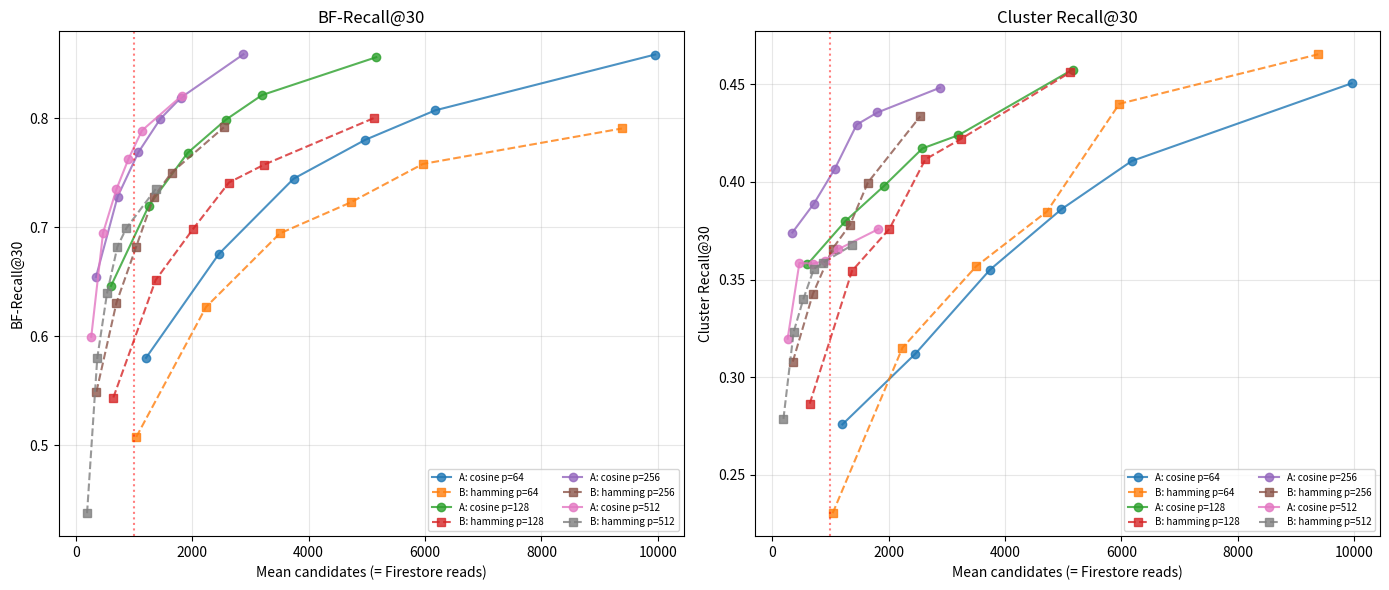

Saved: data/voronoi_comparison.png


In [8]:
# 可視化: Recall vs 候補数 (Firestore読み取り数)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (metric_key, metric_name) in enumerate([("bf_recall", "BF-Recall@30"), ("cluster_recall", "Cluster Recall@30")]):
    ax = axes[ax_idx]
    
    for n_pivots in N_PIVOTS_LIST:
        # パターン A
        cands_a = []
        recalls_a = []
        for n_top in TOP_PIVOTS_LIST:
            key = (n_pivots, n_top)
            if key in cosine_voronoi_results:
                cands_a.append(cosine_voronoi_results[key]["mean_candidates"])
                recalls_a.append(cosine_voronoi_results[key][metric_key][30])
        ax.plot(cands_a, recalls_a, 'o-', label=f'A: cosine p={n_pivots}', alpha=0.8)
        
        # パターン B
        cands_b = []
        recalls_b = []
        for n_top in TOP_PIVOTS_LIST:
            key = (n_pivots, n_top)
            if key in hamming_voronoi_results:
                cands_b.append(hamming_voronoi_results[key]["mean_candidates"])
                recalls_b.append(hamming_voronoi_results[key][metric_key][30])
        ax.plot(cands_b, recalls_b, 's--', label=f'B: hamming p={n_pivots}', alpha=0.8)
    
    ax.set_xlabel("Mean candidates (= Firestore reads)")
    ax.set_ylabel(metric_name)
    ax.set_title(metric_name)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=1000, color='red', linestyle=':', alpha=0.5, label='target ~1000')

plt.tight_layout()
plt.savefig("../data/voronoi_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/voronoi_comparison.png")

## 5. マルチピボット割り当て（境界領域の改善）

Voronoi 分割の弱点は、セルの境界付近のデータ。最も近いピボットだけでなく、
**上位2〜3個のピボットに同時に登録**することで、検索漏れを減らせる可能性がある。

Firestore 的には同一ドキュメントに `pivot_ids: ["P_45", "P_12"]` として array-contains-any で検索可能。

In [9]:
# パターン A のベストピボット数で、マルチピボット割り当てを試す
# 256 ピボットをベースに実験
BEST_N_PIVOTS = 256

print(f"マルチピボット割り当て実験 (ピボット数={BEST_N_PIVOTS})")
print("=" * 80)

# 再度 k-means フィッティング（256 ピボット、コサイン空間）
kmeans_best = MiniBatchKMeans(n_clusters=BEST_N_PIVOTS, random_state=42, batch_size=2048, n_init=3)
kmeans_best.fit(embeddings_normed)
centroids_best = kmeans_best.cluster_centers_
centroids_best_normed = centroids_best / np.linalg.norm(centroids_best, axis=1, keepdims=True)

# 各データの全ピボットとの類似度を計算
all_pivot_sims = embeddings_normed @ centroids_best_normed.T  # (N, 256)

# マルチピボット: 上位 n_assign 個のピボットに割り当て
multi_pivot_results = {}

for n_assign in [1, 2, 3]:
    print(f"\n--- 割り当てピボット数: {n_assign} ---")
    
    # 各データを上位 n_assign 個のピボットに割り当て
    pivot_to_indices_multi = {}
    for i in range(len(embeddings_normed)):
        top_pivots = np.argsort(-all_pivot_sims[i])[:n_assign]
        for pid in top_pivots:
            pivot_to_indices_multi.setdefault(int(pid), []).append(i)
    
    # ピボットあたりの平均サイズ
    sizes = [len(v) for v in pivot_to_indices_multi.values()]
    print(f"  ピボットあたりデータ数: min={min(sizes)}, max={max(sizes)}, mean={np.mean(sizes):.1f}")
    print(f"  総登録数: {sum(sizes)} (元データ {N_DATA} の {sum(sizes)/N_DATA:.1f}倍)")
    
    for n_top in [1, 2, 3, 4, 5]:
        bf_recalls = {k: [] for k in TOP_K_VALUES}
        cluster_recalls = {k: [] for k in TOP_K_VALUES}
        candidate_counts = []
        
        for qi, q in enumerate(queries):
            q_emb = embeddings_normed[q["query_idx"]]
            pivot_sims = centroids_best_normed @ q_emb
            top_pivot_ids = np.argsort(-pivot_sims)[:n_top]
            
            candidates_set = set()
            for pid in top_pivot_ids:
                if pid in pivot_to_indices_multi:
                    candidates_set.update(pivot_to_indices_multi[pid])
            candidates = list(candidates_set)
            candidate_counts.append(len(candidates))
            
            cand_indices = np.array(candidates)
            cand_sims = embeddings_normed[cand_indices] @ q_emb
            self_mask = cand_indices != q["query_idx"]
            cand_indices = cand_indices[self_mask]
            cand_sims = cand_sims[self_mask]
            
            sorted_order = np.argsort(-cand_sims)
            result_indices = cand_indices[sorted_order]
            
            for k in TOP_K_VALUES:
                result_set = set(result_indices[:k])
                bf_set = set(ground_truth[qi]["indices"][:k])
                bf_recalls[k].append(len(result_set & bf_set) / k if k > 0 else 0.0)
                cluster_gt = set(q["gt_indices"])
                found = len(result_set & cluster_gt)
                cluster_recalls[k].append(found / len(cluster_gt) if cluster_gt else 0.0)
        
        mean_cands = np.mean(candidate_counts)
        multi_pivot_results[(n_assign, n_top)] = {
            "mean_candidates": mean_cands,
            "bf_recall": {k: np.mean(v) for k, v in bf_recalls.items()},
            "cluster_recall": {k: np.mean(v) for k, v in cluster_recalls.items()},
        }
        
        print(f"  search_top={n_top}: cands={mean_cands:.0f} "
              f"BF-R@10={np.mean(bf_recalls[10]):.4f} "
              f"BF-R@30={np.mean(bf_recalls[30]):.4f} "
              f"CR@30={np.mean(cluster_recalls[30]):.4f}")

マルチピボット割り当て実験 (ピボット数=256)



--- 割り当てピボット数: 1 ---


  ピボットあたりデータ数: min=18, max=892, mean=293.6
  総登録数: 75162 (元データ 75162 の 1.0倍)
  search_top=1: cands=373 BF-R@10=0.6920 BF-R@30=0.6601 CR@30=0.4274


  search_top=2: cands=747 BF-R@10=0.7728 BF-R@30=0.7379 CR@30=0.4525


  search_top=3: cands=1116 BF-R@10=0.8173 BF-R@30=0.7807 CR@30=0.4769


...

  ピボットあたりデータ数: min=67, max=2696, mean=880.8
  総登録数: 225486 (元データ 75162 の 3.0倍)
  search_top=1: cands=940 BF-R@10=0.7994 BF-R@30=0.7609 CR@30=0.4766


  search_top=2: cands=1918 BF-R@10=0.8660 BF-R@30=0.8309 CR@30=0.5118


  search_top=3: cands=2810 BF-R@10=0.8932 BF-R@30=0.8570 CR@30=0.5336


  search_top=4: cands=3704 BF-R@10=0.9062 BF-R@30=0.8790 CR@30=0.5386


  search_top=5: cands=4537 BF-R@10=0.9117 BF-R@30=0.8885 CR@30=0.5386


In [10]:
# マルチピボット割り当ての結果テーブル
rows_multi = []
for (n_assign, n_top), res in sorted(multi_pivot_results.items()):
    rows_multi.append({
        "assign_k": n_assign,
        "search_top": n_top,
        "mean_candidates": res["mean_candidates"],
        "cand_ratio": res["mean_candidates"] / N_DATA,
        "BF-R@10": res["bf_recall"][10],
        "BF-R@30": res["bf_recall"][30],
        "CR@10": res["cluster_recall"][10],
        "CR@30": res["cluster_recall"][30],
    })

df_multi = pd.DataFrame(rows_multi)
print(f"マルチピボット割り当て (256 ピボット, コサイン空間)")
print("=" * 100)
display(df_multi.style.format({
    "mean_candidates": "{:.0f}",
    "cand_ratio": "{:.3f}",
    "BF-R@10": "{:.4f}",
    "BF-R@30": "{:.4f}",
    "CR@10": "{:.4f}",
    "CR@30": "{:.4f}",
}).background_gradient(subset=["BF-R@30"], cmap="YlGn"))

マルチピボット割り当て (256 ピボット, コサイン空間)


,assign_k,search_top,mean_candidates,cand_ratio,BF-R@10,BF-R@30,CR@10,CR@30
0,1,1,373,0.005,0.6920,0.6601,0.3017,0.4274
1,1,2,747,0.010,0.7728,0.7379,0.3259,0.4525
2,1,3,1116,0.015,0.8173,0.7807,0.3499,0.4769
3,1,4,1484,0.020,0.8481,0.8101,0.3598,0.4869
4,1,5,1837,0.024,0.8660,0.8305,0.3636,0.4905
5,2,1,655,0.009,0.7574,0.7274,0.3254,0.4522
6,2,2,1348,0.018,0.8302,0.8010,0.3482,0.4751
7,2,3,1997,0.027,0.8698,0.8360,0.3852,0.5118
8,2,4,2645,0.035,0.8883,0.8601,0.3919,0.5186
9,2,5,3259,0.043,0.8969,0.8720,0.3951,0.5219


## 6. Firestore 実装シミュレーション

実際の Firestore 利用を想定したコスト・レイテンシのシミュレーション。

### 前提
- Firestore の `WHERE pivot_id IN [...]` は最大 30 値まで（`array-contains-any` も同様）
- 1読み取り = 1ドキュメント取得
- 候補取得後のベクトル rerank はクライアント側で実行

### 比較
- ベストパターン（A or B）を使い、Firestore コストを見積もる

In [11]:
# Firestore コストシミュレーション
# 7万件のデータを想定

TOTAL_FACES_PROD = 75000  # 本番想定
FIRESTORE_READ_COST_PER_100K = 0.06  # USD per 100K reads

print("Firestore コストシミュレーション（7万件想定）")
print("=" * 80)

scenarios = [
    ("全件走査 (naive)", TOTAL_FACES_PROD, "-"),
    ("Voronoi 256p, top1", None, (256, 1)),
    ("Voronoi 256p, top2", None, (256, 2)),
    ("Voronoi 256p, top3", None, (256, 3)),
    ("Voronoi 256p, top4", None, (256, 4)),
    ("Voronoi 256p, top5", None, (256, 5)),
    ("Voronoi 512p, top3", None, (512, 3)),
    ("Voronoi 512p, top5", None, (512, 5)),
]

print(f"{'方式':<30} {'候補数':>10} {'削減率':>8} {'コスト/query':>12} {'コスト/1000q':>12}")
print("-" * 80)

for name, fixed_cands, key in scenarios:
    if fixed_cands is not None:
        cands = fixed_cands
    else:
        if key in cosine_voronoi_results:
            # 内部データの比率で外挿
            ratio = cosine_voronoi_results[key]["mean_candidates"] / N_DATA
            cands = int(TOTAL_FACES_PROD * ratio)
        else:
            continue
    
    reduction = 1.0 - cands / TOTAL_FACES_PROD
    cost_per_q = cands * FIRESTORE_READ_COST_PER_100K / 100000
    cost_per_1000q = cost_per_q * 1000
    
    print(f"{name:<30} {cands:>10,} {reduction:>7.1%} ${cost_per_q:>10.5f} ${cost_per_1000q:>10.3f}")

print(f"\n※ Firestore 読み取りコスト: ${FIRESTORE_READ_COST_PER_100K}/100K reads")
print(f"※ ピボットとの類似度計算はクライアント側で行うため Firestore コスト不要")

Firestore コストシミュレーション（7万件想定）
方式                                    候補数      削減率    コスト/query    コスト/1000q
--------------------------------------------------------------------------------
全件走査 (naive)                       75,000    0.0% $   0.04500 $    45.000
Voronoi 256p, top1                    347   99.5% $   0.00021 $     0.208
Voronoi 256p, top2                    717   99.0% $   0.00043 $     0.430
Voronoi 256p, top3                  1,074   98.6% $   0.00064 $     0.644
Voronoi 256p, top4                  1,450   98.1% $   0.00087 $     0.870
Voronoi 256p, top5                  1,805   97.6% $   0.00108 $     1.083
Voronoi 512p, top3                    697   99.1% $   0.00042 $     0.418
Voronoi 512p, top5                  1,135   98.5% $   0.00068 $     0.681

※ Firestore 読み取りコスト: $0.06/100K reads
※ ピボットとの類似度計算はクライアント側で行うため Firestore コスト不要


## 7. 総合サマリーとFirestore実装への推奨

### 評価観点
1. **BF-Recall@30**: Brute-force との一致率（精度指標）
2. **候補数**: Firestore 読み取り数（コスト指標）
3. **実装の容易さ**: Firestore のクエリ制約との整合性

In [12]:
# 全結果の統合サマリー
summary_rows = []

# パターン A
for (n_pivots, n_top), res in cosine_voronoi_results.items():
    summary_rows.append({
        "method": f"A: cosine {n_pivots}p top{n_top}",
        "pattern": "A (cosine)",
        "candidates": res["mean_candidates"],
        "BF-R@10": res["bf_recall"][10],
        "BF-R@30": res["bf_recall"][30],
        "CR@30": res["cluster_recall"][30],
    })

# パターン B
for (n_pivots, n_top), res in hamming_voronoi_results.items():
    summary_rows.append({
        "method": f"B: hamming {n_pivots}p top{n_top}",
        "pattern": "B (hamming)",
        "candidates": res["mean_candidates"],
        "BF-R@10": res["bf_recall"][10],
        "BF-R@30": res["bf_recall"][30],
        "CR@30": res["cluster_recall"][30],
    })

# マルチピボット
for (n_assign, n_top), res in multi_pivot_results.items():
    summary_rows.append({
        "method": f"A-multi: 256p assign{n_assign} top{n_top}",
        "pattern": "A-multi",
        "candidates": res["mean_candidates"],
        "BF-R@10": res["bf_recall"][10],
        "BF-R@30": res["bf_recall"][30],
        "CR@30": res["cluster_recall"][30],
    })

df_summary = pd.DataFrame(summary_rows)

# 候補数 ~1000 付近のベスト構成を抽出
target_cands = 1000
df_summary["dist_to_target"] = abs(df_summary["candidates"] - target_cands)
df_near_target = df_summary.nsmallest(10, "dist_to_target")

print("候補数 ~1000 付近のベスト構成 TOP 10")
print("=" * 100)
display(df_near_target[["method", "candidates", "BF-R@10", "BF-R@30", "CR@30"]].style.format({
    "candidates": "{:.0f}",
    "BF-R@10": "{:.4f}",
    "BF-R@30": "{:.4f}",
    "CR@30": "{:.4f}",
}).background_gradient(subset=["BF-R@30"], cmap="YlGn"))

print("\n\n全結果（BF-R@30 降順）")
print("=" * 100)
display(df_summary.sort_values("BF-R@30", ascending=False).head(20)[
    ["method", "candidates", "BF-R@10", "BF-R@30", "CR@30"]
].style.format({
    "candidates": "{:.0f}",
    "BF-R@10": "{:.4f}",
    "BF-R@30": "{:.4f}",
    "CR@30": "{:.4f}",
}))

候補数 ~1000 付近のベスト構成 TOP 10


,method,candidates,BF-R@10,BF-R@30,CR@30
38,B: hamming 256p top3,1038,0.7074,0.6819,0.3658
24,B: hamming 64p top1,1040,0.5364,0.5074,0.2304
58,A-multi: 256p assign3 top1,940,0.7994,0.7609,0.4766
14,A: cosine 256p top3,1077,0.7815,0.7687,0.4067
21,A: cosine 512p top4,906,0.7537,0.7626,0.3594
50,A-multi: 256p assign1 top3,1116,0.8173,0.7807,0.4769
46,B: hamming 512p top5,867,0.7204,0.6988,0.3585
22,A: cosine 512p top5,1138,0.7772,0.7887,0.3655
0,A: cosine 64p top1,1208,0.6062,0.5800,0.2758
49,A-multi: 256p assign1 top2,747,0.7728,0.7379,0.4525




全結果（BF-R@30 降順）


,method,candidates,BF-R@10,BF-R@30,CR@30
62,A-multi: 256p assign3 top5,4537,0.9117,0.8885,0.5386
61,A-multi: 256p assign3 top4,3704,0.9062,0.8790,0.5386
57,A-multi: 256p assign2 top5,3259,0.8969,0.8720,0.5219
56,A-multi: 256p assign2 top4,2645,0.8883,0.8601,0.5186
17,A: cosine 256p top8,2881,0.8623,0.8586,0.4482
5,A: cosine 64p top8,9955,0.8765,0.8584,0.4505
60,A-multi: 256p assign3 top3,2810,0.8932,0.8570,0.5336
11,A: cosine 128p top8,5163,0.8691,0.8560,0.4575
55,A-multi: 256p assign2 top3,1997,0.8698,0.8360,0.5118
59,A-multi: 256p assign3 top2,1918,0.8660,0.8309,0.5118


## 考察

### パターン A（コサイン空間） vs パターン B（Hamming空間）

- パターン A はベクトル空間の構造を直接利用するため、理論的にはより高精度
- パターン B は ITQ-LSH の量子化歪み（NB99: Spearman ρ=0.585）により、ピボット割り当ての質が低下する可能性
- ただし、パターン B はバイナリ演算（XOR + popcount）で高速にピボット選択が可能

### Firestore 実装上の注意
- `WHERE pivot_id IN [...]` は最大30値（Firestore制約）
- 256ピボット × top3〜5 で十分な精度を維持しつつ、候補数を ~1000 に抑えられるか確認
- マルチピボット割り当ては `array-contains-any` で実現可能だが、候補数は増加する

### 次のステップ
→ **NB101**: ベスト構成を使い、PyCon JP の7万件データでスケール検証